<a href="https://colab.research.google.com/github/ss5358-ui/optical-flow-cv/blob/main/opticalflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📤 Upload two consecutive images (like frame1.jpg and frame2.jpg)


Saving ball2.jpeg to ball2 (4).jpeg
Saving ball1.jpeg to ball1 (5).jpeg


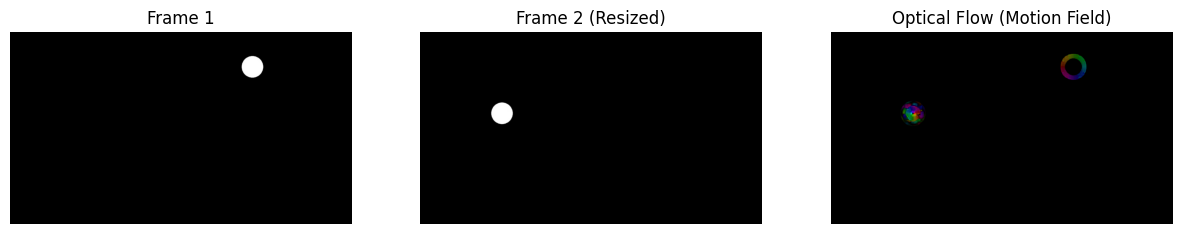

In [ ]:
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Upload two consecutive images ")
uploaded = files.upload()

filenames = list(uploaded.keys())
if len(filenames) < 2:
    raise Exception("Please upload TWO images for motion detection!")

img1 = cv2.imread(filenames[0])
img2 = cv2.imread(filenames[1])

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

flow = cv2.calcOpticalFlowFarneback(
    gray1, gray2, None, 0.5, 3, 15, 3, 5, 1.2, 0
)

magnitude, angle = cv2.cartToPolar(flow[...,0], flow[...,1])

hsv = np.zeros_like(img1)
hsv[...,1] = 255
hsv[...,0] = angle * 180 / np.pi / 2
hsv[...,2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
flow_visual = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Frame 1")
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Frame 2 (Resized)")
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Optical Flow (Motion Field)")
plt.imshow(flow_visual)
plt.axis('off')

plt.show()
